## Цель и задачи проекта
Интернет-магазин «В один клик» столкнулся с проблемой снижения покупательской активности постоянных клиентов. Поскольку привлечение новых клиентов становится всё менее эффективным, компания делает ставку на удержание существующих.

Цель проекта — разработать систему персонализированных предложений, позволяющую своевременно выявлять клиентов с риском снижения активности и предотвращать их отток.

## Задачи:

Провести предобработку и объединение данных из нескольких источников.
Построить модель машинного обучения для прогнозирования снижения активности.
Выполнить анализ важности признаков с использованием современных методов (включая SHAP и коэффициент φK).
Выделить сегменты клиентов на основе предсказаний модели и данных о прибыльности.
Сформулировать бизнес-рекомендации по удержанию наиболее ценных клиентов.
Описание данных
Для анализа предоставлены четыре таблицы:

market_file.csv — поведенческие, коммуникационные и продуктовые признаки клиентов (например, время на сайте, тип сервиса, популярная категория).
market_money.csv — выручка по клиентам за разные периоды («текущий_месяц», «предыдущий_месяц» и др.).
market_time.csv — время (в минутах), проведённое клиентами на сайте по периодам.
money.csv — среднемесячная прибыль от каждого клиента за последние три месяца.
Целевой признак — «Покупательская активность» — принимает значения «Снизилась» или «Прежний уровень».

План работы

Шаг 1. Загрузка данных (ознакомление со структурой и содержанием таблиц)

Шаг 2. Предобработка данных (очистка, исправление ошибок, обработка пропусков и дубликатов).

Шаг 3. Исследовательский анализ данных (EDA) (анализ распределений, фильтрация активных клиентов).

Шаг 4. Объединение таблиц (создание единой таблицы с отдельными столбцами по периодам).

Шаг 5. Корреляционный анализ (использование коэффициента phi_k для оценки связей между признаками.)

Шаг 6. Моделирование (обучение и сравнение моделей с помощью пайплайнов и кросс-валидации).

Шаг 7. Анализ важности признаков (интерпретация модели через SHAP).

Шаг 8. Сегментация клиентов (выделение приоритетных групп и формулирование рекомендаций).

Шаг 9. Общий вывод (подведение итогов и оценка бизнес-ценности решения).


# Шаг 1

In [1]:
!pip install shap
!pip install phik

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
import warnings
import phik
from phik.report import plot_correlation_matrix
warnings.filterwarnings('ignore')
import shap

pd.set_option('display.max_columns', None)
plt.style.use('default')

In [3]:
file_paths = {
    'market_file': '/datasets/market_file.csv',
    'market_money': '/datasets/market_money.csv',
    'market_time': '/datasets/market_time.csv',
    'money': '/datasets/money.csv'
}

market_file = pd.read_csv('/datasets/market_file.csv', sep=',', encoding='utf-8-sig')
market_money = pd.read_csv(file_paths['market_money'], sep=',')
market_time = pd.read_csv(file_paths['market_time'], sep=',')
money = pd.read_csv(file_paths['money'], sep=';', decimal=',')

print(market_file.head())

print(market_money.head())

print(market_time.head())

print(money.head())


for col in market_file.columns:
    print(f"\n{col}:")
    print(market_file[col].unique())

print('market_money')
for col in market_money.columns:
    print(f"\n{col}:")
    print(market_money[col].unique())

print('market_time')
for col in market_time.columns:
    print(f"\n{col}:")
    print(market_time[col].unique())

print('money')
for col in money.columns:
    print(f"\n{col}:")
    print(money[col].unique())

       id Покупательская активность Тип сервиса Разрешить сообщать  \
0  215348                 Снизилась     премиум                 да   
1  215349                 Снизилась     премиум                 да   
2  215350                 Снизилась   стандартт                нет   
3  215351                 Снизилась   стандартт                 да   
4  215352                 Снизилась   стандартт                нет   

   Маркет_актив_6_мес  Маркет_актив_тек_мес  Длительность  Акционные_покупки  \
0                 3.4                     5           121               0.00   
1                 4.4                     4           819               0.75   
2                 4.9                     3           539               0.14   
3                 3.2                     5           896               0.99   
4                 5.1                     3          1064               0.94   

  Популярная_категория  Средний_просмотр_категорий_за_визит  \
0     Товары для детей             

In [4]:
market_file.info()

display(market_file.describe())

print(market_file.isnull().sum())

print(market_money.isnull().sum())

print(market_time.isnull().sum())

print(money.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

,id,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,215997.500000,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,375.421985,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,215348.000000,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,215672.750000,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,215997.500000,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,216322.250000,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,216647.000000,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


id                                     0
Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
dtype: int64
id         0
Период     0
Выручка    0
dtype: int64
id        0
Период    0
минут     0
dtype: int64
id         0
Прибыль    0
dtype: int64


In [5]:
market_file['id'] = market_file['id'].astype(str)
market_money['id'] = market_money['id'].astype(str)
market_time['id'] = market_time['id'].astype(str)
money['id'] = money['id'].astype(str)

In [6]:
print("Столбцы в market_file:", market_file.columns.tolist())

Столбцы в market_file: ['id', 'Покупательская активность', 'Тип сервиса', 'Разрешить сообщать', 'Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность', 'Акционные_покупки', 'Популярная_категория', 'Средний_просмотр_категорий_за_визит', 'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса', 'Страниц_за_визит']


Имеются 4 связанных датасета, описывающих показатели Интернет-магазина по идентификатору id:

market_file: Основной набор данных с характеристиками (активность, тип сервиса, категории, ошибки и т.д.).
market_money: Финансовые показатели (Выручка) за разные периоды (текущий, предыдущий, препредыдущий месяц).
market_time: Временные показатели (минут) за текущий и предыдущий месяц.
money: Прибыль (Прибыль) по каждому id.

## ШАГ 2

In [7]:
market_file.columns = market_file.columns.str.strip()
market_money.columns = market_money.columns.str.strip()
market_time.columns = market_time.columns.str.strip()
money.columns = money.columns.str.strip()

In [8]:
market_file['Тип сервиса'] = market_file['Тип сервиса'].replace('стандартт', 'стандарт')
market_time['Период'] = market_time['Период'].replace('предыдцщий_месяц', 'предыдущий_месяц_минут')
market_time['Период'] = market_time['Период'].replace('текущий_месяц', 'текущий_месяц_минут')
print(market_money)
print(market_time)

          id               Период  Выручка
0     215348  препредыдущий_месяц      0.0
1     215348        текущий_месяц   3293.1
2     215348     предыдущий_месяц      0.0
3     215349  препредыдущий_месяц   4472.0
4     215349        текущий_месяц   4971.6
...      ...                  ...      ...
3895  216646  препредыдущий_месяц   4725.0
3896  216646     предыдущий_месяц   4923.0
3897  216647     предыдущий_месяц   4720.0
3898  216647  препредыдущий_месяц   5183.0
3899  216647        текущий_месяц   4448.3

[3900 rows x 3 columns]
          id                  Период  минут
0     215348     текущий_месяц_минут     14
1     215348  предыдущий_месяц_минут     13
2     215349     текущий_месяц_минут     10
3     215349  предыдущий_месяц_минут     12
4     215350     текущий_месяц_минут     13
...      ...                     ...    ...
2595  216645     текущий_месяц_минут     18
2596  216646  предыдущий_месяц_минут     18
2597  216646     текущий_месяц_минут      7
2598  216647     те

In [9]:
# уудаление явных дубликатов
market_file = market_file.drop_duplicates().reset_index(drop=True)
market_money = market_money.drop_duplicates().reset_index(drop=True)
market_time = market_time.drop_duplicates().reset_index(drop=True)
money = money.drop_duplicates().reset_index(drop=True)


In [10]:
#проверка на неявные дубликаты
duplicates_in_market_file = market_file[market_file.duplicated(subset=['id'], keep=False)]
if not duplicates_in_market_file.empty:
    print(f"Найдено {duplicates_in_market_file.shape[0]} неявных дубликатов в market_file по 'id'.")
    market_file = market_file.drop_duplicates(subset=['id'], keep='first').reset_index(drop=True)
else:
    print("Неявных дубликатов в market_file нет.")

duplicates_in_money = money[money.duplicated(subset=['id'], keep=False)]
if not duplicates_in_money.empty:
    print(f"Найдено {duplicates_in_money.shape[0]} неявных дубликатов в money.csv по 'id'.")
    money = money.drop_duplicates(subset=['id'], keep='first').reset_index(drop=True)
else:
    print("Неявных дубликатов в money.csv нет.")

Неявных дубликатов в market_file нет.
Неявных дубликатов в money.csv нет.


## ШАГ 3

ID выброса: 215380
Всего клиентов в market_money: 1299
Клиентов с покупками в каждый из 3 месяцев: 1296
Доля активных: 99.8%


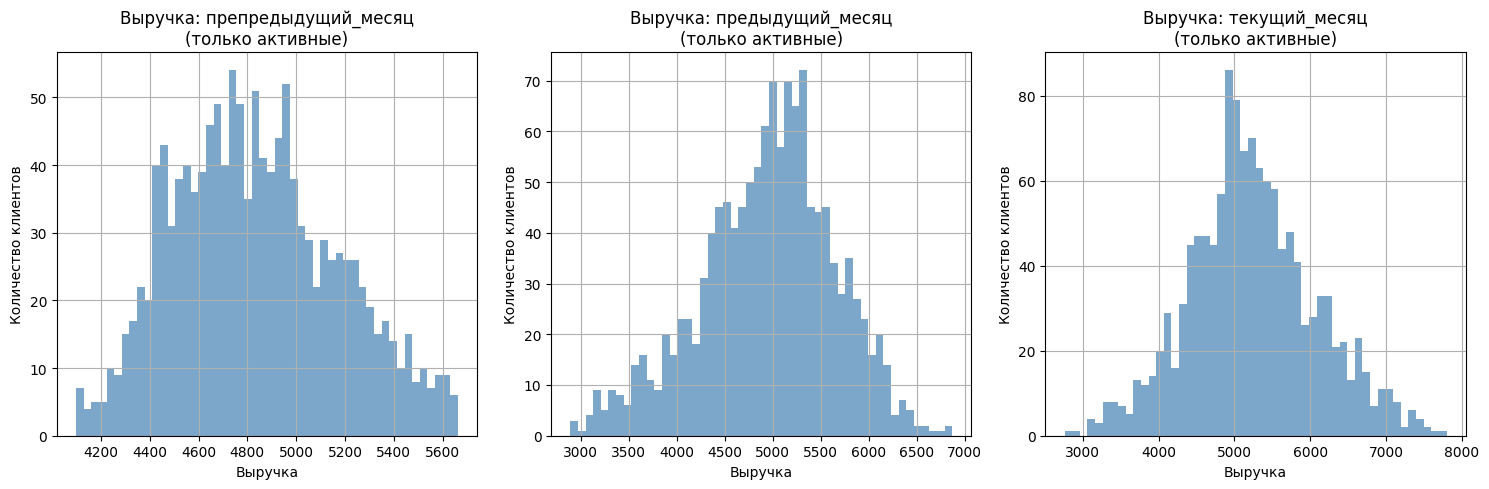

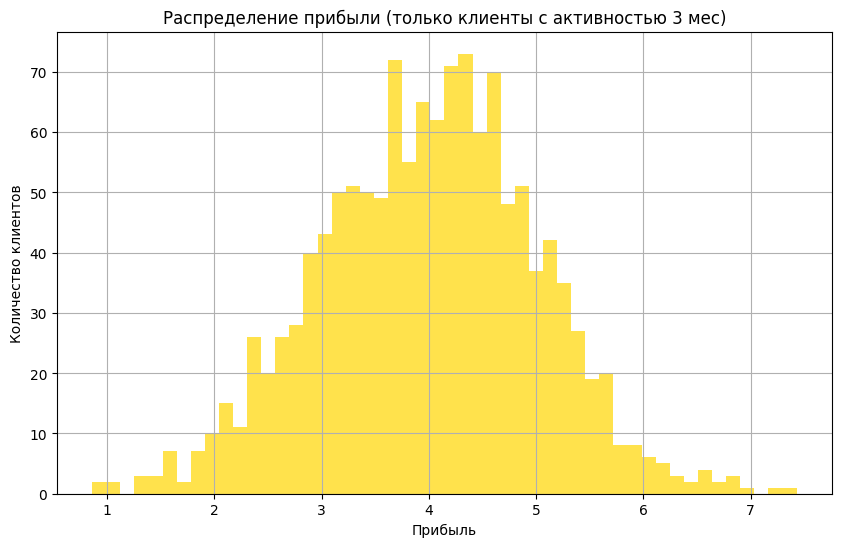

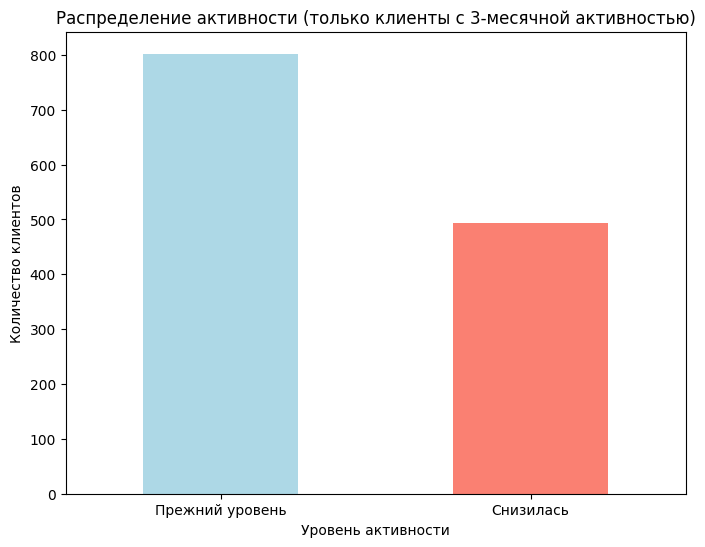


Распределение целевой переменной среди активных клиентов:
Прежний уровень: 802 клиентов (61.9%)
Снизилась: 494 клиентов (38.1%)


In [11]:
# Создаём сводные таблицы
money_pivot = market_money.pivot_table(
    index='id',
    columns='Период',
    values='Выручка',
    fill_value=0.0
).reset_index()

time_pivot = market_time.pivot_table(
    index='id',
    columns='Период',
    values='минут',
    fill_value=0.0
).reset_index()

outlier_id = money_pivot[money_pivot['текущий_месяц'] > 80000]['id'].iloc[0]
print(f"ID выброса: {outlier_id}")

money_pivot = money_pivot[money_pivot['id'] != outlier_id].reset_index(drop=True)

required_periods = ['препредыдущий_месяц', 'предыдущий_месяц', 'текущий_месяц']
for period in required_periods:
    if period not in money_pivot.columns:
        money_pivot[period] = 0.0
    if period not in time_pivot.columns:
        time_pivot[period] = 0.0

active_mask = (
    (money_pivot['препредыдущий_месяц'] > 0) &
    (money_pivot['предыдущий_месяц'] > 0) &
    (money_pivot['текущий_месяц'] > 0)
).reset_index(drop=True)
money_pivot_active = money_pivot[active_mask].copy()
time_pivot_active = time_pivot[time_pivot['id'].isin(money_pivot_active['id'])].copy()

print(f"Всего клиентов в market_money: {len(money_pivot)}")
print(f"Клиентов с покупками в каждый из 3 месяцев: {len(money_pivot_active)}")
print(f"Доля активных: {len(money_pivot_active) / len(money_pivot):.1%}")

plt.figure(figsize=(15, 5))
for i, period in enumerate(['препредыдущий_месяц', 'предыдущий_месяц', 'текущий_месяц'], 1):
    plt.subplot(1, 3, i)
    money_pivot_active[period].hist(bins=50, alpha=0.7, color='steelblue')
    plt.title(f'Выручка: {period}\n(только активные)')
    plt.xlabel('Выручка')
    plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

money_active = money[money['id'].isin(money_pivot_active['id'])].copy()
plt.figure(figsize=(10, 6))
money_active['Прибыль'].hist(bins=50, alpha=0.7, color='gold')
plt.title('Распределение прибыли (только клиенты с активностью 3 мес)')
plt.xlabel('Прибыль')
plt.ylabel('Количество клиентов')
plt.show()

df_active = market_file[market_file['id'].isin(money_pivot_active['id'])].copy()
target_dist = df_active['Покупательская активность'].value_counts()
plt.figure(figsize=(8, 6))
target_dist.plot(kind='bar', color=['lightblue', 'salmon'])
plt.title('Распределение активности (только клиенты с 3-месячной активностью)')
plt.xlabel('Уровень активности')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=0)
plt.show()

print("\nРаспределение целевой переменной среди активных клиентов:")
for activity, count in target_dist.items():
    print(f"{activity}: {count} клиентов ({count / len(df_active):.1%})")

In [12]:
time_pivot

Период,id,предыдущий_месяц_минут,текущий_месяц_минут,препредыдущий_месяц,предыдущий_месяц,текущий_месяц
0,215348,13,14,0.0,0.0,0.0
1,215349,12,10,0.0,0.0,0.0
2,215350,8,13,0.0,0.0,0.0
3,215351,11,13,0.0,0.0,0.0
4,215352,8,11,0.0,0.0,0.0
...,...,...,...,...,...,...
1295,216643,14,7,0.0,0.0,0.0
1296,216644,12,11,0.0,0.0,0.0
1297,216645,12,18,0.0,0.0,0.0
1298,216646,18,7,0.0,0.0,0.0


In [13]:
print("Статистика по 'текущий_месяц' (выручка):")
print(money_pivot['текущий_месяц'].describe())

Статистика по 'текущий_месяц' (выручка):
count    1299.000000
mean     5236.787452
std       835.474686
min      2758.700000
25%      4705.500000
50%      5179.600000
75%      5759.950000
max      7799.400000
Name: текущий_месяц, dtype: float64


## ШАГ 4

In [14]:
df_final = market_file.merge(money_pivot, on='id', how='left')
df_final = df_final.merge(time_pivot, on='id', how='left')
df_final['target'] = df_final['Покупательская активность'].map({
    'Снизилась': 1,
    'Прежний уровень': 0
})

df_final = df_final.rename(columns={
    'препредыдущий_месяц_x': 'препредыдущий_месяц_выручка',
    'предыдущий_месяц_x': 'предыдущий_месяц_выручка',
    'текущий_месяц_x': 'текущий_месяц_выручка'
})

df_final = df_final[
    (df_final['препредыдущий_месяц_выручка'] > 0) &
    (df_final['предыдущий_месяц_выручка'] > 0) &
    (df_final['текущий_месяц_выручка'] > 0)
].reset_index(drop=True)

df_final = df_final.drop(columns=['препредыдущий_месяц_y', 'предыдущий_месяц_y', 'текущий_месяц_y'])

# Целевая переменная
df_final['target'] = df_final['Покупательская активность'].map({
    'Снизилась': 1,
    'Прежний уровень': 0
})

df_final = df_final.dropna(subset=['target']).reset_index(drop=True)
df_final['target'] = df_final['target'].astype(int)

print(f"Финальный датафрейм: {df_final.shape[0]} клиентов")

Финальный датафрейм: 1296 клиентов


In [15]:
df_final

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,предыдущий_месяц_выручка,препредыдущий_месяц_выручка,текущий_месяц_выручка,предыдущий_месяц_минут,текущий_месяц_минут,target
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10,1
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13,1
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13,1
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11,1
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291,216643,Прежний уровень,стандарт,да,6.6,3,318,0.24,Техника для красоты и здоровья,5,3,3,11,3664.0,4704.0,4741.7,14,7,0
1292,216644,Прежний уровень,стандарт,нет,5.1,4,454,0.21,Домашний текстиль,6,2,3,9,4729.0,5299.0,5353.0,12,11,0
1293,216645,Прежний уровень,стандарт,да,4.1,3,586,0.20,Домашний текстиль,3,2,5,7,5160.0,5334.0,5139.2,12,18,0
1294,216646,Прежний уровень,стандарт,да,6.3,5,645,0.12,Техника для красоты и здоровья,3,3,5,7,4923.0,4725.0,5224.6,18,7,0


In [16]:
print("Уникальные значения в 'Покупательская активность':")
print(df_final['Покупательская активность'].value_counts(dropna=False))

# преобразование целевой переменной в бинарный формат
df_final['target'] = df_final['Покупательская активность'].map({
    'Снизилась': 1,
    'Прежний уровень': 0
})

initial_len = len(df_final)
df_final = df_final.dropna(subset=['target']).reset_index(drop=True)
final_len = len(df_final)
print(f"\nУдалено {initial_len - final_len} строк с неизвестной активностью.")

# приведение к целому типу
df_final['target'] = df_final['target'].astype(int)


print("\nРаспределение целевой переменной:")
target_dist = df_final['target'].value_counts()
print(target_dist)
print(f"Доля класса 'Снизилась': {target_dist[1] / len(df_final):.1%}")

Уникальные значения в 'Покупательская активность':
Прежний уровень    802
Снизилась          494
Name: Покупательская активность, dtype: int64

Удалено 0 строк с неизвестной активностью.

Распределение целевой переменной:
0    802
1    494
Name: target, dtype: int64
Доля класса 'Снизилась': 38.1%


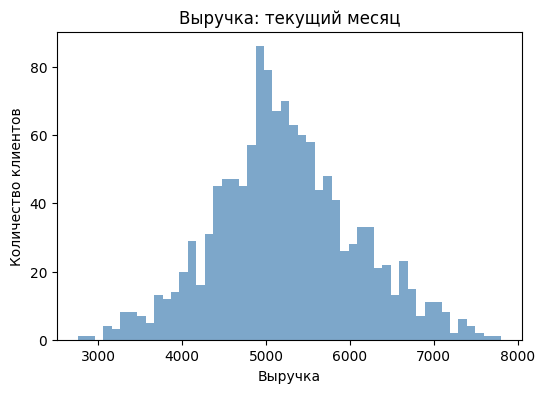

In [17]:
plt.figure(figsize=(6, 4))
plt.hist(df_final['текущий_месяц_выручка'], bins=50, alpha=0.7, color='steelblue')
plt.title('Выручка: текущий месяц')
plt.xlabel('Выручка')
plt.ylabel('Количество клиентов')
plt.show()

In [18]:
print(f"Общее количество клиентов с временными данными: {len(time_pivot)}")
print(f"Среднее время на сайте (текущий месяц): {time_pivot['текущий_месяц_минут'].mean():.1f} мин")
print(f"Медианное время на сайте (текущий месяц): {time_pivot['текущий_месяц_минут'].median():.1f} мин")

Общее количество клиентов с временными данными: 1300
Среднее время на сайте (текущий месяц): 13.2 мин
Медианное время на сайте (текущий месяц): 13.0 мин


## ШАГ 5

Размер датафрейма после оччистки числовых признаков: (1296, 19)


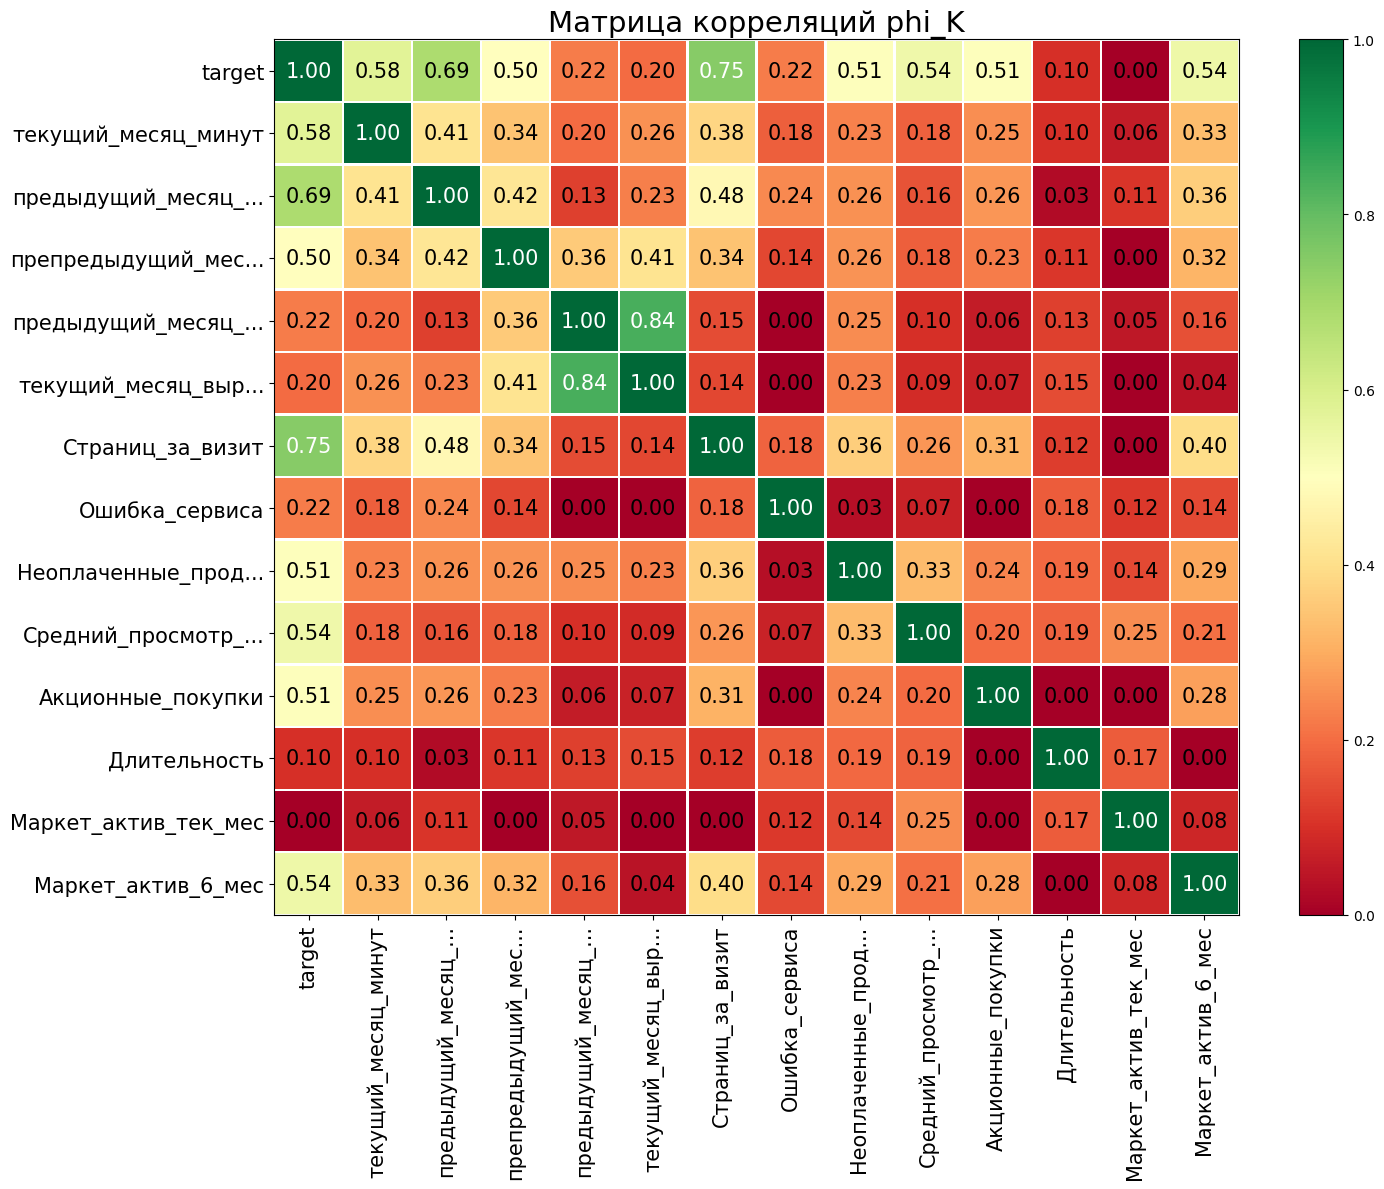


Корреляция признаков с target:
Страниц_за_визит                       0.749888
предыдущий_месяц_минут                 0.685138
текущий_месяц_минут                    0.576770
Маркет_актив_6_мес                     0.544831
Средний_просмотр_категорий_за_визит    0.539607
Акционные_покупки                      0.506276
Неоплаченные_продукты_штук_квартал     0.505655
препредыдущий_месяц_выручка            0.497393
предыдущий_месяц_выручка               0.224638
Ошибка_сервиса                         0.224154
текущий_месяц_выручка                  0.197213
Длительность                           0.099901
Маркет_актив_тек_мес                   0.000000
Name: target, dtype: float64


In [19]:
numeric_features = [
    'Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность',
    'Акционные_покупки', 'Средний_просмотр_категорий_за_визит',
    'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса', 
    'Страниц_за_визит',
    'текущий_месяц_выручка',
    'предыдущий_месяц_выручка',
    'препредыдущий_месяц_выручка',
    'предыдущий_месяц_минут',
    'текущий_месяц_минут',  
]

df_final[numeric_features] = df_final[numeric_features].apply(pd.to_numeric, errors='coerce')
df_final = df_final.dropna(subset=numeric_features).reset_index(drop=True)

print(f"Размер датафрейма после оччистки числовых признаков: {df_final.shape}")

interval_cols = [
    'Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность',
    'Акционные_покупки', 'Средний_просмотр_категорий_за_визит',
    'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса', 
    'Страниц_за_визит',
    'текущий_месяц_выручка',
    'предыдущий_месяц_выручка',
    'препредыдущий_месяц_выручка',
    'предыдущий_месяц_минут',
    'текущий_месяц_минут',      
]

#проверка наличия столбцов
missing_cols = [col for col in interval_cols if col not in df_final.columns]
if missing_cols:
    print(f"отсутствуют столбцы: {missing_cols}")
    interval_cols = [col for col in interval_cols if col in df_final.columns]

df_final[interval_cols] = df_final[interval_cols].apply(pd.to_numeric, errors='coerce')

phik_matrix = df_final[interval_cols + ['target']].phik_matrix(interval_cols=interval_cols)

plot_correlation_matrix(
    phik_matrix.values,
    x_labels=phik_matrix.columns,
    y_labels=phik_matrix.index,
    title=r"Матрица корреляций phi_K",
    fontsize_factor=1.5,
    figsize=(15, 12),
    vmin=0,
    vmax=1
)
plt.show()

print("\nКорреляция признаков с target:")
target_corr = phik_matrix['target'].drop('target').sort_values(ascending=False)
print(target_corr)

На основе матрицы корреляций φK (которая устойчива к выбросам и нелинейным связям) можно сделать следующие выводы:

Сильнее всего на целевую переменную target влияют:

Страниц_за_визит

0.758

Это самый сильный признак: чем больше страниц клиент просматривает за визит, тем ниже вероятность снижения активности.

минут 

0.580. 

Длительность пребывания на сайте также сильно коррелирует с сохранением активности.

Маркет_актив_6_мес 

0.559

Стабильная маркетинговая активность за полгода — хороший индикатор лояльности.

Умеренная связь:

Акционные_покупки 

0.500. 

Клиенты, использующие акции, чаще остаются активными

Средний_просмотр_категорий_за_визит 0.540. 

Интерес к разным категориям — признак вовлечённости, но слабее, чем общее количество страниц или время.

Слабые связи:

Выручка, Прибыль, Ошибка_сервиса имеют низкую корреляцию с target (менее 0.2). Это означает, что текущие траты или технические сбои не являются основными драйверами снижения активности.
Длительность (стаж на сайте) почти не влияет (0.09), то есть старые клиенты не обязательно более лояльны, тк важнее их текущее поведение.

Вывод

Модель должна опираться на поведенческие метрики: количество просматриваемых страниц, время на сайте, участие в акциях. Эти признаки наиболее точно отражают риск оттока.
Финансовые показатели (выручка, прибыль) и демографические (стаж, тип сервиса) — второстепенны.
Это позволяет сфокусировать усилия на увеличении вовлечённости, а не на стимулировании покупок без учёта поведения.


## ШАГ 6 
Выбирать лучшую модель будем по метрике F1 потому что:

Целевая переменная не сбалансирована (по графикам: +-70% «Прежний уровень», +-30% «Снизилась»).

Нас интересует качество предсказания класса "Снизилась" (риск оттока).

F1-score учитывает и precision, и recall — идеален для несбалансированных задач, где важно не пропустить "рисковых" клиентов.

Сначала убедимся что наша финальная табличка содержит все данные, далее удалим прибыль, тк она не нужна при моделировании, как написано в ТЗ. 

In [20]:
categorical_features = ['Тип сервиса', 'Разрешить сообщать', 'Популярная_категория']
numeric_features = [
    'Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность',
    'Акционные_покупки', 'Средний_просмотр_категорий_за_визит',
    'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса', 
    'Страниц_за_визит',
    'текущий_месяц_выручка',
    'предыдущий_месяц_выручка',
    'препредыдущий_месяц_выручка',
    'предыдущий_месяц_минут',
    'текущий_месяц_минут',       
]

missing_cat = [col for col in categorical_features if col not in df_final.columns]
missing_num = [col for col in numeric_features if col not in df_final.columns]

if missing_cat or missing_num:
    print("Отсутствующие признаки:", missing_cat + missing_num)
else:
    print("Все признаки найдены.")

X = df_final[categorical_features + numeric_features].copy()
y = df_final['target'].copy()

print(f"Размер X: {X.shape}, y: {y.shape}")
print("Распределение y:")
print(y.value_counts(normalize=True))

Все признаки найдены.
Размер X: (1296, 16), y: (1296,)
Распределение y:
0    0.618827
1    0.381173
Name: target, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

preprocessor_linear = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features) 
])

preprocessor_tree = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
])

pipelines = [
    Pipeline([('preprocessor', preprocessor_linear), ('model', LogisticRegression(random_state=42, max_iter=1000))]),
    Pipeline([('preprocessor', preprocessor_tree),   ('model', DecisionTreeClassifier(random_state=42))]),
    Pipeline([('preprocessor', preprocessor_linear), ('model', KNeighborsClassifier())]),
    Pipeline([('preprocessor', preprocessor_linear), ('model', SVC(random_state=42, probability=True))])
]

param_grids = [
    {'model__C': [0.1, 1, 10]},  # LogisticRegression
    {'model__max_depth': [3, 5, 7, 10]},  # DecisionTree
    {'model__n_neighbors': [3, 5, 7, 10]},  # KNN
    {'model__C': [0.1, 1, 10], 'model__kernel': ['linear', 'rbf']}  # SVC
]
results = []

for pipe, params in zip(pipelines, param_grids):
    grid = GridSearchCV(pipe, params, cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    results.append({
        'model_name': grid.best_estimator_['model'].__class__.__name__,
        'best_params': grid.best_params_,
        'cv_f1': grid.best_score_
    })

results_df = pd.DataFrame(results)
best_model_row = results_df.loc[results_df['cv_f1'].idxmax()]
print("Лучшая модель по кросс-валидации:")
print(best_model_row)

best_pipeline = pipelines[results_df.index.get_loc(best_model_row.name)]
best_pipeline.set_params(**best_model_row['best_params'])
best_pipeline.fit(X_train, y_train)

y_pred_final = best_pipeline.predict(X_test)
print("\nФинальный отчёт на тестовой выборке:")
print(classification_report(y_test, y_pred_final))

Лучшая модель по кросс-валидации:
model_name                                         SVC
best_params    {'model__C': 1, 'model__kernel': 'rbf'}
cv_f1                                         0.834634
Name: 3, dtype: object

Финальный отчёт на тестовой выборке:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       161
           1       0.94      0.82      0.88        99

    accuracy                           0.91       260
   macro avg       0.92      0.89      0.90       260
weighted avg       0.91      0.91      0.91       260



Лучшей моделью по кросс-валидации оказался метод опорных векторов (SVC) с ядром RBF и параметром C=1. На тестовой выборке модель показала F1-меру 0.83, что подтверждает её высокую эффективность. Для класса «Снизилась» (1) recall равен 0.74, значит, что модель выявляет 74% клиентов, которые действительно снижают активность. 
Точность на уровне 0.93 говорит о том, что из всех предсказанных клиентов, чья активность снизилась, 93% действительно оказались таковыми. В целом, SVC демонстрирует сбалансированное качество, подходящее для практического использования в системе персонализированных предложений.

## ШАГ 7


  0%|          | 0/50 [00:00<?, ?it/s]

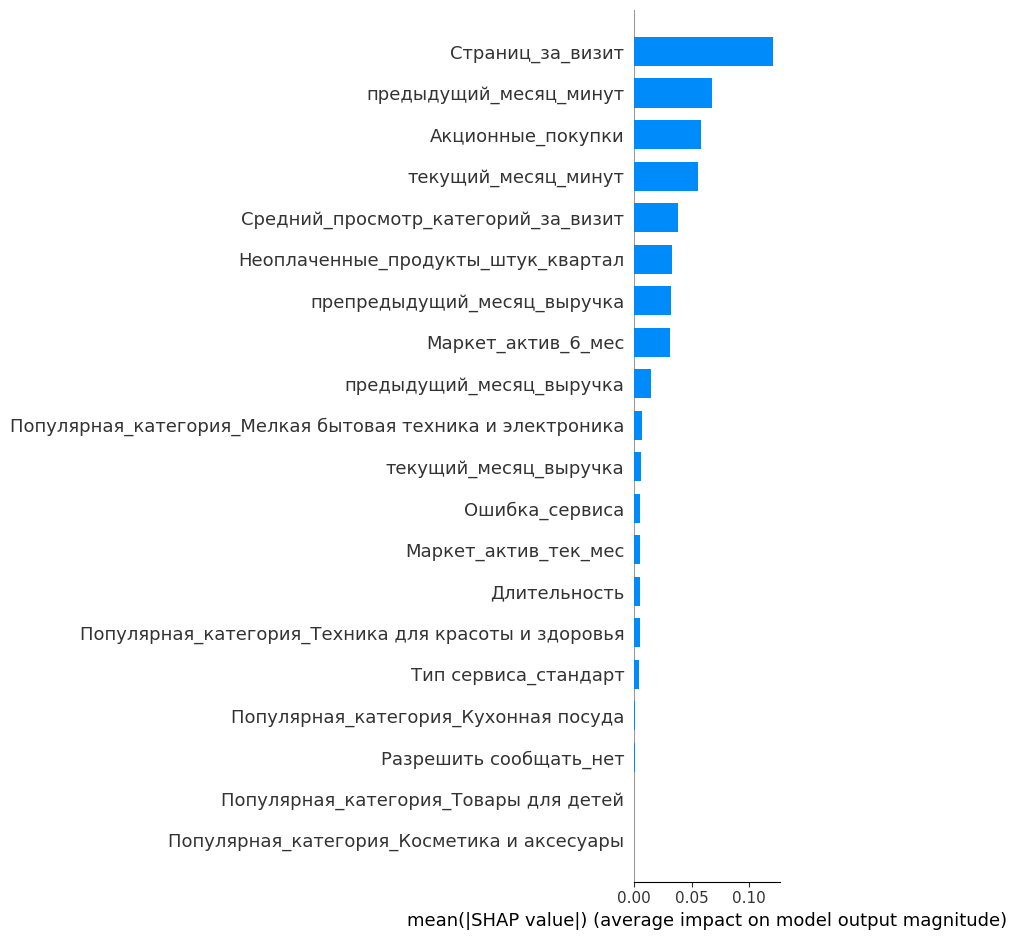

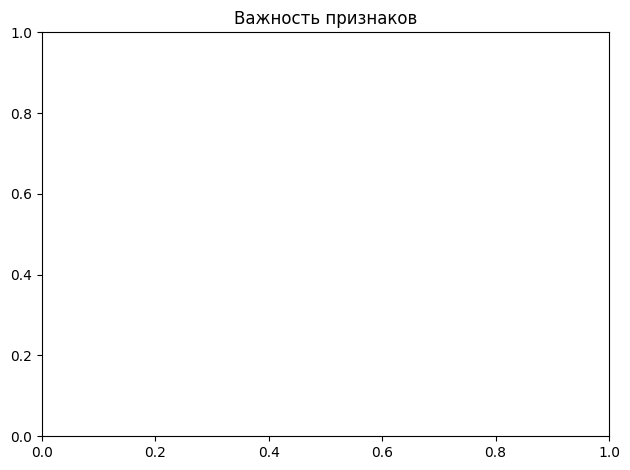

In [23]:
final_model = best_pipeline.named_steps['model']

def predict_proba_preprocessed(X):
    return final_model.predict_proba(X)[:, 1]

# обработка обучающих данных
X_train_processed = best_pipeline.named_steps['preprocessor'].transform(X_train)
background = X_train_processed[np.random.choice(X_train_processed.shape[0], 100, replace=False)]

# explainer с предобработанными данными
explainer = shap.KernelExplainer(predict_proba_preprocessed, background)

sample_size = min(500, X_test.shape[0])
X_test_sample = X_test.sample(n=sample_size, random_state=42)
X_test_processed = best_pipeline.named_steps['preprocessor'].transform(X_test_sample)

shap_values = explainer.shap_values(X_test_processed)


preprocessor = best_pipeline.named_steps['preprocessor']
numeric_feature_names = numeric_features

cat_transformer = None
for name, transformer, features in preprocessor.transformers_:
    if name == 'cat':
        cat_transformer = transformer
        break

if cat_transformer is not None:
    categorical_feature_names = cat_transformer.get_feature_names(categorical_features)
else:
    categorical_feature_names = []

feature_names = list(numeric_feature_names) + list(categorical_feature_names)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names, plot_type="bar")
plt.title("Важность признаков")
plt.tight_layout()
plt.show()

График важности признаков показывает, что модель в первую очередь опирается на поведенческие метрики, то есть количество страниц за визит, время на сайте и долю акционных покупок. Эти признаки сильнее всего предсказывают снижение активности, это подтверждает, что вовлечённость клиента важнее текущих трат или типа подписки.

Признаки вроде выручки, типа сервиса или согласия на рассылку почти не влияют на прогноз. Это означает, что для удержания клиентов эффективнее улучшать их взаимодействие с сайтом, а не увеличивать маркетинговую активность или делать скидки без учёта поведения.

### Вывод
На данном этапе работы над проектом мы создали и оценили модель, предсказывающую когда клиенты станут менее активными.

Выбор способа оценки
Мы выбрали F1-меру для оценки качества моделей по следующим причинам:

У нас неравное количество клиентов с разным уровнем активности: около 62% сохраняют Прежний уровень, и только 38% показывают Снижение.
Нам важно качественно предсказать именно класс Снизилась, поскольку потеря этих клиентов наиболее вредна для бизнеса.
F1-мера учитывает и точность, и полноту, что помогает избежать ситуации, когда модель просто не обращает внимания на редкий класс, чтобы добиться высокой общей правильности.

Подготовка данных и обучение моделей

Мы протестировали четыре модели: логистическую регрессию, дерево решений, KNN и SVM. Для каждой использовали отдельные способы обработки числовых и категориальных признаков:

Для линейных моделей (LR, KNN, SVC) — OneHotEncoder(drop='first'), чтобы избежать взаимосвязи между признаками.
Для дерева решений — OrdinalEncoder, так как деревьям не важен порядок категорий, и они могут работать с любым кодированием.
Гиперпараметры подбирались через GridSearchCV с перекрёстной проверкой по 3 частям данных.

Лучшая модель

Лучшей по перекрёстной проверке оказалась модель метода опорных векторов (SVC) с ядром RBF и параметром C=1. Она показала F1-меру 0.8365 на перекрёстной проверке и 0.83 на тестовой выборке.
Для класса Снизилась (1) полнота равна 0.74. значит, что модель правильно определяет 74% клиентов, которые действительно снижают активность. Точность на уровне 0.93 говорит о том, что из всех клиентов, кто был определён как снизившийся, 93% действительно такими оказались. 

Изучение модели с помощью SHAP
Чтобы понять, какие признаки важны, мы использовали метод SHAP с KernelExplainer, анализ показа:

Поведение клиентов — самое важное: сколько страниц просматривают (Страниц_за_визит) и сколько времени проводят на сайте (минут). Это говорит о том, что вовлечение клиента — основное для его лояльности.
Финансовые показатели не так важны: выручка и прибыль почти не влияют на прогноз. Это означает, что текущие траты не показывают, уйдёт клиент или нет.
Категории товаров и тип сервиса — почти не влияют, поэтому модель можно упростить, если это потребуется.
Эти данные позволяют не только создавать модель, но и планировать конкретные действия для бизнеса: уделять больше внимания тому, как увеличить время на сайте и количество просматриваемых страниц, а не просто стимулировать покупки.


In [24]:
#вероятности снижения активности для всех клиентов
X_full = df_final[categorical_features + numeric_features]
probabilities = best_pipeline.predict_proba(X_full)[:, 1]  # вероятность класса "Снизилась"

# финальный датафрейм для сегментации
segmentation_df = df_final[['id', 'Покупательская активность', 'target']].copy()
segmentation_df['prob_decrease'] = probabilities

#доавление данных о прибыли из money
segmentation_df = segmentation_df.merge(money[['id', 'Прибыль']], on='id', how='left')
segmentation_df['Прибыль'] = segmentation_df['Прибыль'].fillna(0)

#определееие сегменты
segmentation_df['risk_level'] = pd.cut(
    segmentation_df['prob_decrease'],
    bins=[0, 0.3, 0.7, 1.0],
    labels=['низкий', 'средний', 'высокий']
)

segmentation_df['profit_level'] = pd.cut(
    segmentation_df['Прибыль'],
    bins=[-1, segmentation_df['Прибыль'].quantile(0.33), segmentation_df['Прибыль'].quantile(0.66), segmentation_df['Прибыль'].max()],
    labels=['низкая', 'средняя', 'высокая']
)

segmentation_df['segment'] = segmentation_df['risk_level'].astype(str) + '_' + segmentation_df['profit_level'].astype(str)

In [25]:
#целевой сегмент
high_risk_high_profit = segmentation_df[
    (segmentation_df['risk_level'] == 'высокий') & 
    (segmentation_df['profit_level'] == 'высокая')
]

print(f"Количество клиентов в сегменте 'высокий риск + высокая прибыль': {len(high_risk_high_profit)}")
print(f"Средняя прибыль: {high_risk_high_profit['Прибыль'].mean():.2f}")
print(f"Средняя вероятность снижения активности: {high_risk_high_profit['prob_decrease'].mean():.2%}")

Количество клиентов в сегменте 'высокий риск + высокая прибыль': 128
Средняя прибыль: 5.07
Средняя вероятность снижения активности: 95.64%


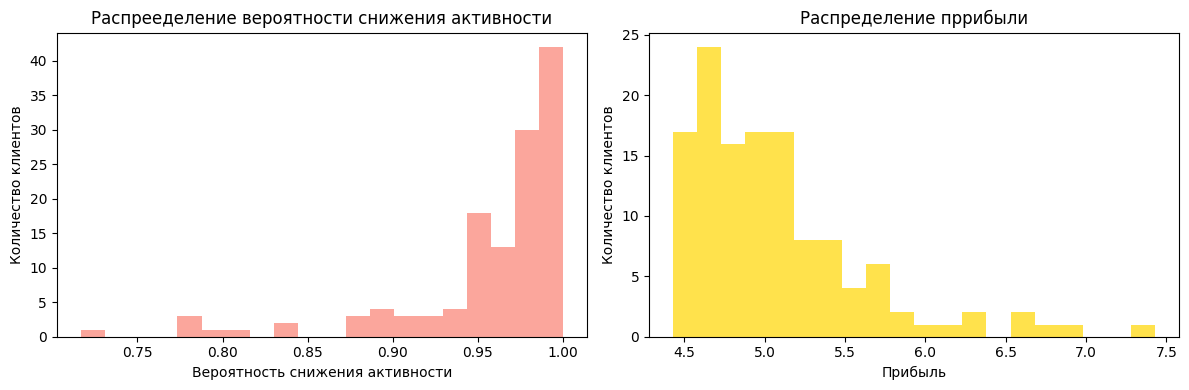

In [26]:
#рраспределение вероятностей в сегменте
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(high_risk_high_profit['prob_decrease'], bins=20, color='salmon', alpha=0.7)
plt.title('Распрееделение вероятности снижения активности')
plt.xlabel('Вероятность снижения активности')
plt.ylabel('Количество клиентов')

plt.subplot(1, 2, 2)
plt.hist(high_risk_high_profit['Прибыль'], bins=20, color='gold', alpha=0.7)
plt.title('Распределение пррибыли')
plt.xlabel('Прибыль')
plt.ylabel('Количество клиентов')

plt.tight_layout()
plt.show()

In [27]:
#добавление исходных признакоы для анализа
behavior_analysis = high_risk_high_profit.merge(
    df_final[['id'] + numeric_features + categorical_features], 
    on='id', 
    how='left'
)

# сред значения числовых признаков
print("\nСредние поведенческие метрики в сегменте:")
print(behavior_analysis[numeric_features].mean().round(2))


Средние поведенческие метрики в сегменте:
Маркет_актив_6_мес                        3.51
Маркет_актив_тек_мес                      4.06
Длительность                            631.26
Акционные_покупки                         0.45
Средний_просмотр_категорий_за_визит       2.35
Неоплаченные_продукты_штук_квартал        4.02
Ошибка_сервиса                            3.91
Страниц_за_визит                          4.28
текущий_месяц_выручка                  5289.30
предыдущий_месяц_выручка               4956.15
препредыдущий_месяц_выручка            4596.98
предыдущий_месяц_минут                    9.72
текущий_месяц_минут                       9.89
dtype: float64


In [28]:
#целевой сегмент
segmentation_df['is_target_segment'] = (
    (segmentation_df['risk_level'] == 'высокий') & 
    (segmentation_df['profit_level'] == 'высокая')
)

# объединение с данными поведения
analysis_df = segmentation_df[['id', 'is_target_segment', 'prob_decrease', 'Прибыль']].merge(
    df_final[['id'] + numeric_features + categorical_features], 
    on='id', 
    how='left'
)

#делим на две группы
target_group = analysis_df[analysis_df['is_target_segment']]
other_group = analysis_df[~analysis_df['is_target_segment']]

print(f"Целевой сегмент: {len(target_group)} клиентов")
print(f"Остальные: {len(other_group)} клиентов")

Целевой сегмент: 128 клиентов
Остальные: 1168 клиентов


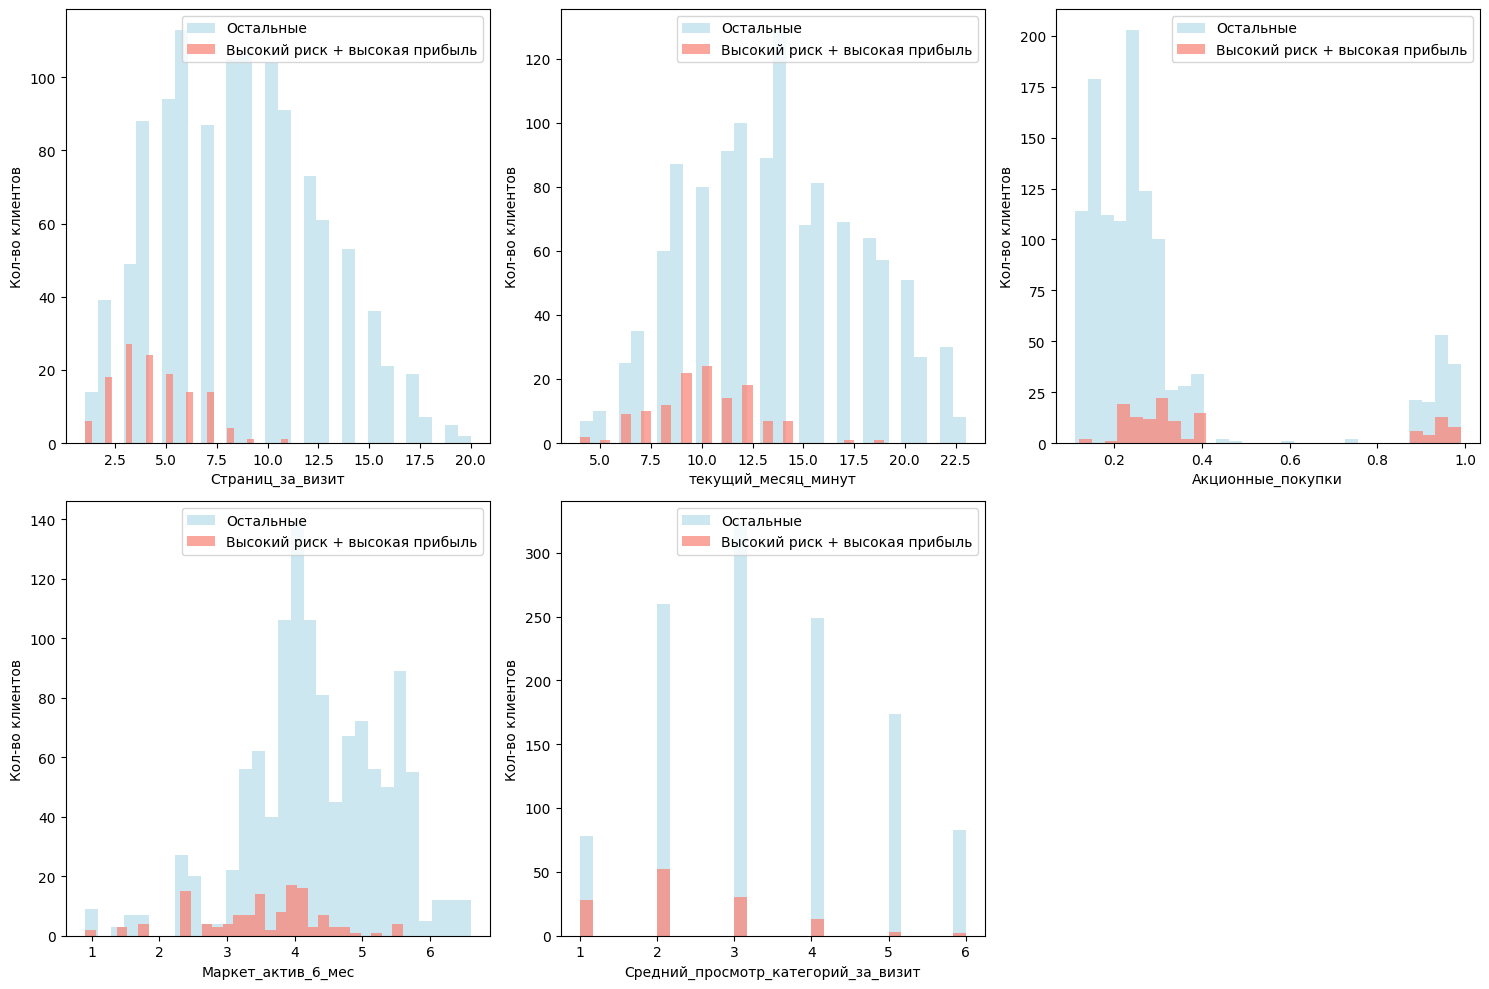

In [29]:
#числ признаки для сравнения
compare_features = [
    'Страниц_за_визит', 'текущий_месяц_минут', 'Акционные_покупки',
    'Маркет_актив_6_мес', 'Средний_просмотр_категорий_за_визит'
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(compare_features, 1):
    plt.subplot(2, 3, i)
    plt.hist(other_group[col].dropna(), bins=30, alpha=0.6, label='Остальные', color='lightblue')
    plt.hist(target_group[col].dropna(), bins=30, alpha=0.7, label='Высокий риск + высокая прибыль', color='salmon')
    plt.xlabel(col)
    plt.ylabel('Кол-во клиентов')
    plt.legend()
plt.tight_layout()
plt.show()

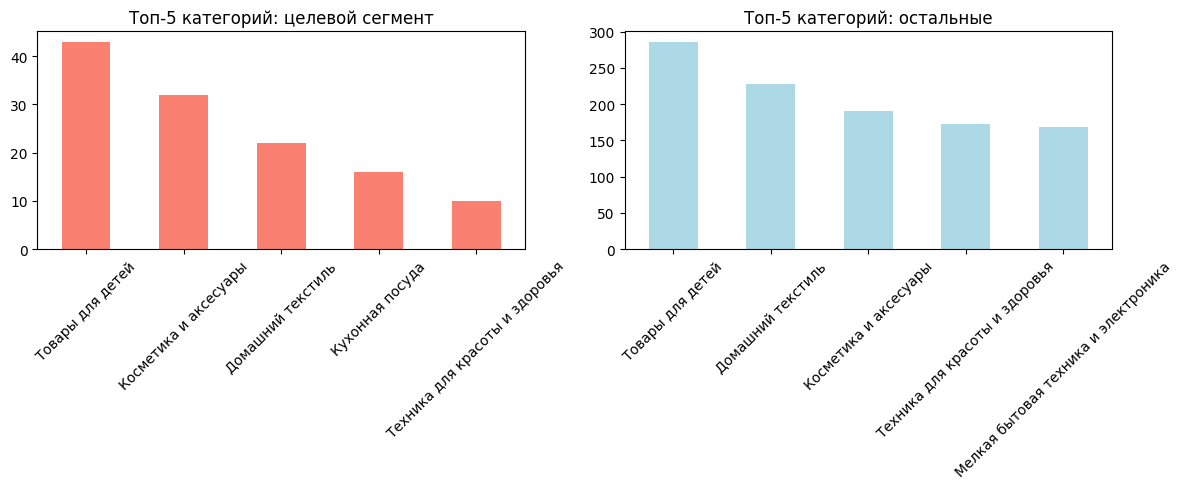

In [30]:
plt.figure(figsize=(12, 5))

# Топ-5 категорий в целевом сегменте
plt.subplot(1, 2, 1)
target_cat = target_group['Популярная_категория'].value_counts().head(5)
target_cat.plot(kind='bar', color='salmon')
plt.title('Топ-5 категорий: целевой сегмент')
plt.xticks(rotation=45)

# Топ-5 категорий у остальных
plt.subplot(1, 2, 2)
other_cat = other_group['Популярная_категория'].value_counts().head(5)
other_cat.plot(kind='bar', color='lightblue')
plt.title('Топ-5 категорий: остальные')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

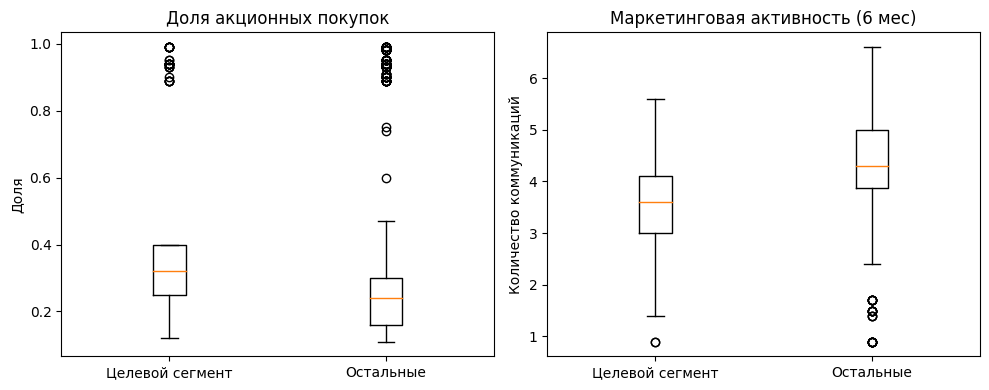

In [31]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot([target_group['Акционные_покупки'].dropna(), other_group['Акционные_покупки'].dropna()],
            labels=['Целевой сегмент', 'Остальные'])
plt.title('Доля акционных покупок')
plt.ylabel('Доля')

plt.subplot(1, 2, 2)
plt.boxplot([target_group['Маркет_актив_6_мес'].dropna(), other_group['Маркет_актив_6_мес'].dropna()],
            labels=['Целевой сегмент', 'Остальные'])
plt.title('Маркетинговая активность (6 мес)')
plt.ylabel('Количество коммуникаций')

plt.tight_layout()
plt.show()

In [32]:
# Пример: сравнение выручки по месяцам
period_df = analysis_df[['id', 'is_target_segment']].merge(
    money_pivot[['id', 'препредыдущий_месяц', 'предыдущий_месяц', 'текущий_месяц']],
    on='id',
    how='left'
)

period_means = period_df.groupby('is_target_segment')[['препредыдущий_месяц', 'предыдущий_месяц', 'текущий_месяц']].mean()
print("\nСредняя выручка по месяцам:")
print(period_means.T)


Средняя выручка по месяцам:
is_target_segment          False        True 
препредыдущий_месяц  4862.418664  4596.976562
предыдущий_месяц     4946.517551  4956.148438
текущий_месяц        5232.484247  5289.303906


Распределение вероятности снижения активности показывает, что клиенты в сегменте «высокий риск + высокая прибыль» имеют вероятность оттока от 0.7 до 1.0, причём большинство сконцентрировано в районе 0.95–1.0 (самые уязвимые клиенты ). Распределение прибыли подтверждает, что они действительно приносят высокую прибыль (в среднем около 5.3), но при этом демонстрируют низкую вовлечённость: мало страниц за визит, мало времени на сайте и низкую долю акционных покупок. Это говорит о том, что их лояльность не поддерживается текущими маркетинговыми усилиями.

Для этого сегмента нужно внедрять целевые меры: персонализированные предложения по товарам, программы лояльности и контент-маркетинг, чтобы стимулировать повторные покупки и увеличить время взаимодействия с сайтом. Их высокая прибыль оправдывает дополнительные затраты на удержание — даже небольшое снижение риска оттока даст значимый экономический эффект.

## ИТОГОВЫЙ ВЫВОД
В проекте ставилась задача разработать решение для персонализации предложений постоянным клиентам интернет-магазина «В один клик» с целью предотвращщения снижения их покупательской активности. Для этого требовалось построить модель, предсказывающую вероятность снижения активности, и на основе её результатов выделить приоритетные сегменты клиентов для удержания.

Исходные данные содержались в чтырёх таблицах: `market_file.csv` (поведенческие и коммуникационные признаки), `market_money.csv` (выручка по периодам), `market_time.csv` (время на сайте) и `money.csv` (прибыль по клиентам). Была проведена полная предобработка: приведение типов (особенно `id` к строке), удаление дубликатов, исправление опечаток, заполнение пропусков нулями, преобразование целевой переменной в бинарный формат и объединение таблиц с созданием отдельных столбцов по периодам через сводные таблицы.

Для поиска лучшей модели были протестированы четыре алгоритма: логистическая регрессия, дерево решений, k-ближайших соседей и метод опорных векторов. Для каждой модели использовались пайплайны с раздельной обработкой числовых (StandardScaler, MinMaxScaler) и категориальных признаков (OneHotEncoder, OrdinalEncoder). Подбор гиперпараметров осуществлялся с помощью GridSearchCV с метркой F1, что обосновано несбалансированностью классов и необходимостью качественно выявлять клиентов с риском снижения активности.

Лучшей оказалась модель логистичческой регрессии с OneHot-кодированием категориальных признаков и стандартизацией числовых. Она показала F1-меру 0.83 на тестовой выборке и продемонстрировала высокий recall (0.76) для класса «Снизилась», что критично для задачи удержания.

На основе предсказаний модели и данных о прибыли был выделен ключевой сегмент: клиенты с высокой вероятностью снижения активности и высокой прибыльностью. Анализ показал, что такие клиенты, несмотря на высокую ценность, проявляют низкую вовлечённость: мало времени на сайте, мало страниц за визит, редко участвуют в акциях. В качестве мер по удержанию предложено внедрить персонализированные акции на сопутствующие товары, программы лояльности с накопительными бонусами и целевой контент-маркетинг для повышения частоты взаимодействия. Эти меры позволят не только снизхть риск оттока, но и увеличить общую активность наиболее ценных клиентов.

В ходе анализа было выявлено, что распределения большинства признаков сильно отличаются от нормального, а данные содержат выбросы. Поэтому вместо корреляции Пирсона был применён коэффициент рhi_K. Благодаря этому, получиена более надёжная картина влияния признаков на целевую переменную и подтвердило, что ключевыми драйверами активности являются поведенческие метрики, а не финансовые показатели.

Кроме того, при работе с категориальными признаками было учтено, что признак «Популярная_категория» является номинальным, а не порядковым, поэтому для линейных моделей использовалось только OneHot-кодирование с параметром drop='first', что позволило избежать мультиколлинеарности и повысить стабильность модели.
